In [8]:
import sys
!{sys.executable} -m pip install torchmetrics

# **Notebook 1 – Dataset Creation for Twin Spirals**
Variant 3 - Twin Spirals With Gradient Clipping:

Goal: generate a binary two-spiral dataset that demands a strongly nonlinear decision boundary.
Steps:
Create 700 points per class by sampling theta on [0, 4pi], setting r = linspace(0.2, 1.2, 700), and converting the polar coordinates to Cartesian coordinates with small Gaussian noise added to both radius and angle.
Build class 0 from (r*sin(theta), r*cos(theta)) and class 1 from (r*sin(theta + pi), r*cos(theta + pi)), then stack both classes into one feature matrix.
Shuffle the full dataset with a fixed seed and create an 80%/20% stratified train/test split.
Convert all feature arrays to torch.float32 tensors of shape (n, 2) and all labels to torch.float32 tensors of shape (n, 1).
Plot the full spiral dataset, print the tensor shapes and class counts, and verify that the spirals remain visibly intertwined but not collapsed by noise.
Hints: keep the random seed explicit, use np.column_stack for coordinate assembly, and avoid excessive noise that destroys the spiral geometry

In [6]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

RANDOM_SEED = 10563
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

install: missing destination file operand after 'torchmetrics'
Try 'install --help' for more information.


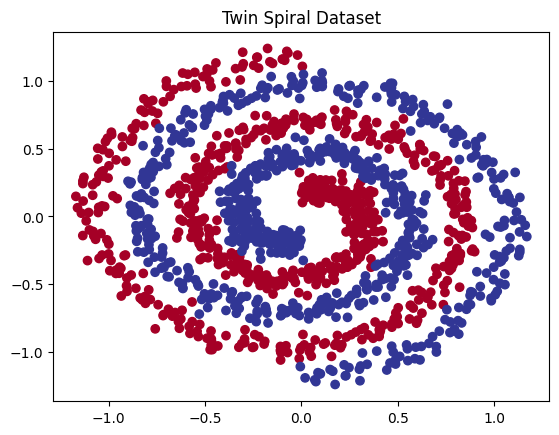

Shapes: torch.Size([1120, 2]) torch.Size([280, 2]) torch.Size([1120, 1]) torch.Size([280, 1])
Class counts: (array([0., 1.]), array([700, 700]))


In [2]:
# Generating spirals
n_points = 700
theta = np.linspace(0, 4*np.pi, n_points)
r = np.linspace(0.2, 1.2, n_points)
noise_r = np.random.normal(0, 0.05, n_points)
noise_theta = np.random.normal(0, 0.05, n_points)

# Class 0
x0 = (r + noise_r) * np.sin(theta + noise_theta)
y0 = (r + noise_r) * np.cos(theta + noise_theta)
class0 = np.column_stack((x0, y0))
labels0 = np.zeros((n_points, 1))

# Class 1
x1 = (r + noise_r) * np.sin(theta + np.pi + noise_theta)
y1 = (r + noise_r) * np.cos(theta + np.pi + noise_theta)
class1 = np.column_stack((x1, y1))
labels1 = np.ones((n_points, 1))

# Combine
X = np.vstack((class0, class1))
y = np.vstack((labels0, labels1))

#SHUFFLLE AND SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y
)

# Convert to torch tensors
X_train = torch.from_numpy(X_train).float()
X_test = torch.from_numpy(X_test).float()
y_train = torch.from_numpy(y_train).float()
y_test = torch.from_numpy(y_test).float()

# Visualization
plt.scatter(X[:, 0], X[:, 1], c=y.flatten(), cmap=plt.cm.RdYlBu)
plt.title("Twin Spiral Dataset")
plt.show()

print("Shapes:", X_train.shape, X_test.shape, y_train.shape, y_test.shape)
print("Class counts:", np.unique(y, return_counts=True))

# **Notebook 2 – Model Subclassing nn.Module**
Goal: create a residual fully connected classifier that can preserve useful intermediate spiral features.
Steps:
Subclass nn.Module and name the model SpiralResidualClassifier.
Define fc1 = Linear(2, 32), fc2 = Linear(32, 32), and fc3 = Linear(32, 1) together with ReLU activations.
In forward(), compute h1 = ReLU(fc1(x)), then h2 = ReLU(fc2(h1) + h1) so the residual addition happens entirely in hidden space.
Pass h2 through fc3 and confirm with a dry run that the model returns logits of shape (batch_size, 1).
Print the model, the output tensor shape for a sample batch, and the number of trainable parameters.
Hints: do not add the raw input directly to a hidden tensor of different width, and check that both tensors in the residual sum have identical shapes.

In [3]:
import torch
from torch import nn

class SpiralResidualClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(2, 32)
        self.fc2 = nn.Linear(32, 32)
        self.fc3 = nn.Linear(32, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        h1 = self.relu(self.fc1(x))
        h2 = self.relu(self.fc2(h1) + h1)  # residual connection
        out = self.fc3(h2)
        return out

model = SpiralResidualClassifier()
print(model)
sample_logits = model(X_train[:5])
print("Output shape:", sample_logits.shape)
print("Trainable parameters:", sum(p.numel() for p in model.parameters()))

SpiralResidualClassifier(
  (fc1): Linear(in_features=2, out_features=32, bias=True)
  (fc2): Linear(in_features=32, out_features=32, bias=True)
  (fc3): Linear(in_features=32, out_features=1, bias=True)
  (relu): ReLU()
)
Output shape: torch.Size([5, 1])
Trainable parameters: 1185


# **Notebook 3 – Loss Functions and Optimizer**
Variant 3 - Twin Spirals With Gradient Clipping:

Goal: emphasize hard samples in the spiral dataset while keeping the output contract consistent with binary classification.
Steps:
Implement a binary focal loss that starts from raw logits, computes sigmoid probabilities internally, and uses parameters alpha=0.75 and gamma=2.0.
Initialize torch.optim.Adam(model.parameters(), lr=0.001) as the optimizer.
Compare the focal-loss value with standard BCE loss on one mini-batch to confirm that the custom implementation runs correctly.
Verify that the logits and targets both have shape (batch_size, 1) and that the targets remain binary floats in {0.0, 1.0}.
Add a short note explaining why focal loss is useful when many spiral samples become easy early and only the difficult boundary samples dominate later.
Hints: clamp probabilities slightly away from 0 and 1 when computing logarithms inside the custom loss to maintain numerical stability.

In [4]:
class BinaryFocalLoss(nn.Module):
    def __init__(self, alpha=0.75, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.sigmoid = nn.Sigmoid()

    def forward(self, logits, targets):
        probs = self.sigmoid(logits)
        probs = torch.clamp(probs, 1e-6, 1-1e-6)
        pt = torch.where(targets == 1, probs, 1 - probs)
        loss = -self.alpha * (1 - pt) ** self.gamma * torch.log(pt)
        return loss.mean()

loss_fn = BinaryFocalLoss(alpha=0.75, gamma=2.0)
bce_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


logits = model(X_train[:16])
y_batch = y_train[:16]
print("Focal loss:", loss_fn(logits, y_batch).item())
print("BCE loss:", bce_fn(logits, y_batch).item())

Focal loss: 0.18036966025829315
BCE loss: 0.7773276567459106


# **Notebook 4 – Training and Testing Loops**
Goal: stabilize training on the spiral dataset with clipping and explicit checkpoint tracking.
Steps:
Fix the random seed, choose 700 epochs, send the model and tensors to the device, and initialize containers for metrics and the best model state.
In each training epoch, compute train logits, probabilities, predicted labels, focal loss, and training accuracy from the full training tensor.
After loss.backward(), apply torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=2.0) and only then call optimizer.step().
Evaluate on the test set in inference mode, compute test loss and test accuracy, and update the stored best weights when test accuracy improves.
Print the train loss, test loss, train accuracy, test accuracy, and clipped gradient norm every 50 epochs.
Hints: use copy.deepcopy(model.state_dict()) for the best checkpoint so that later parameter updates do not overwrite the saved state.

In [13]:
import copy
from torchmetrics import Accuracy
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)
X_train, X_test = X_train.to(device), X_test.to(device)
y_train, y_test = y_train.to(device), y_test.to(device)

epochs = 700
best_acc = 0.0
best_model_state = copy.deepcopy(model.state_dict())
acc_fn = Accuracy(task="binary").to(device)

train_losses = []
test_losses = []
train_accuracies = []
test_accuracies = []

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()

    logits = model(X_train)
    loss = loss_fn(logits, y_train)
    loss.backward()
    grad_norm = nn.utils.clip_grad_norm_(model.parameters(), max_norm=2.0)
    optimizer.step()

    y_pred = torch.round(torch.sigmoid(logits))
    train_acc = acc_fn(y_pred, y_train.int())

    # Testing
    model.eval()
    with torch.inference_mode():
        test_logits = model(X_test)
        test_loss = loss_fn(test_logits, y_test)
        y_test_pred = torch.round(torch.sigmoid(test_logits))
        test_acc = acc_fn(y_test_pred, y_test.int())

    train_losses.append(loss.item())
    test_losses.append(test_loss.item())
    train_accuracies.append(train_acc.item())
    test_accuracies.append(test_acc.item())

    if test_acc > best_acc:
        best_acc = test_acc
        best_model_state = copy.deepcopy(model.state_dict())

    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {loss:.4f} | Train Acc: {train_acc:.4f} | Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f} | Grad Norm: {grad_norm:.4f}")

print(f"Best test accuracy: {best_acc:.4f}")

Epoch 50/700 | Train Loss: 0.0063 | Train Acc: 0.9946 | Test Loss: 0.0119 | Test Acc: 0.9857 | Grad Norm: 0.0035
Epoch 100/700 | Train Loss: 0.0058 | Train Acc: 0.9946 | Test Loss: 0.0117 | Test Acc: 0.9857 | Grad Norm: 0.0031
Epoch 150/700 | Train Loss: 0.0054 | Train Acc: 0.9946 | Test Loss: 0.0117 | Test Acc: 0.9857 | Grad Norm: 0.0029
Epoch 200/700 | Train Loss: 0.0050 | Train Acc: 0.9955 | Test Loss: 0.0116 | Test Acc: 0.9857 | Grad Norm: 0.0027
Epoch 250/700 | Train Loss: 0.0047 | Train Acc: 0.9964 | Test Loss: 0.0116 | Test Acc: 0.9857 | Grad Norm: 0.0025
Epoch 300/700 | Train Loss: 0.0044 | Train Acc: 0.9964 | Test Loss: 0.0116 | Test Acc: 0.9857 | Grad Norm: 0.0029
Epoch 350/700 | Train Loss: 0.0042 | Train Acc: 0.9973 | Test Loss: 0.0117 | Test Acc: 0.9857 | Grad Norm: 0.0025
Epoch 400/700 | Train Loss: 0.0039 | Train Acc: 0.9973 | Test Loss: 0.0118 | Test Acc: 0.9857 | Grad Norm: 0.0021
Epoch 450/700 | Train Loss: 0.0038 | Train Acc: 0.9982 | Test Loss: 0.0119 | Test Acc: 0.

# **Notebook 5 – Predictions and Decision Boundary**
Goal: inspect how closely the trained model follows the nonlinear twin-spiral structure.
Steps:
Restore the best checkpoint saved during training, switch to evaluation mode, and compute probabilities and predicted labels on the test set.
Plot the decision boundary over a dense mesh grid and overlay the spiral data in the same coordinate system.
Compute an ROC curve together with the AUC value from the test probabilities.
Perform a threshold sweep over values from 0.10 to 0.90, report the threshold with the highest test accuracy, and compare it with the default threshold 0.50.
Write a brief interpretation of whether the remaining errors follow the spiral arms or occur mostly near the outer noisy regions.
Hints: flatten the probability tensor before passing it to scikit-learn metrics, and keep the ROC analysis separate from the threshold-sweep summary.

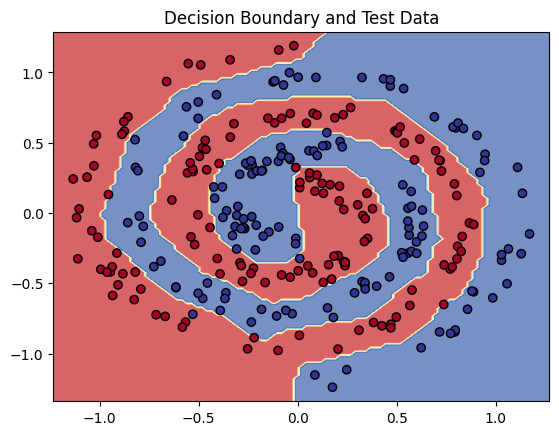

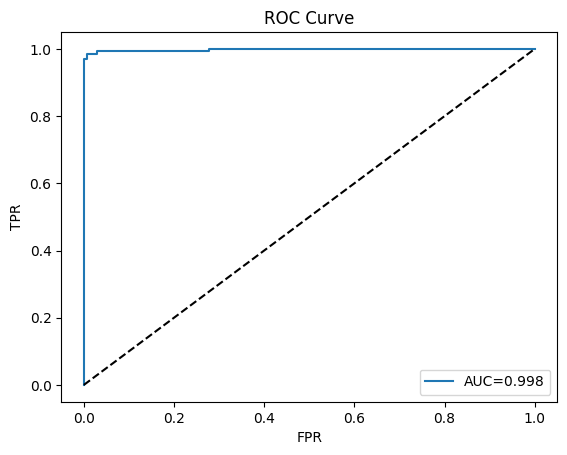

Best threshold: 0.5000000000000001, Best accuracy: 0.9892857142857143


In [14]:
model.load_state_dict(best_model_state)
model.eval()

def plot_decision_boundary(model, X, y):
    import numpy as np
    import matplotlib.pyplot as plt

    model.to("cpu")
    X, y = X.to("cpu"), y.to("cpu")

    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 101),
                         np.linspace(y_min, y_max, 101))

    X_grid = torch.from_numpy(np.column_stack((xx.ravel(), yy.ravel()))).float()
    with torch.inference_mode():
        logits = model(X_grid)
        preds = torch.round(torch.sigmoid(logits)).reshape(xx.shape).numpy()

    plt.contourf(xx, yy, preds, cmap=plt.cm.RdYlBu, alpha=0.7)
    plt.scatter(X[:, 0], X[:, 1], c=y.flatten(), cmap=plt.cm.RdYlBu, edgecolors='k')
    plt.title("Decision Boundary and Test Data")
    plt.show()

plot_decision_boundary(model, X_test, y_test)

from sklearn.metrics import roc_curve, auc

probs = torch.sigmoid(model(X_test)).flatten().detach().cpu().numpy()
fpr, tpr, thresholds = roc_curve(y_test.flatten().cpu().numpy(), probs)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC={roc_auc:.3f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve")
plt.legend()
plt.show()

# Threshold sweep
best_thresh = 0.5
best_acc_val = 0
for t in np.arange(0.1, 0.91, 0.05):
    y_pred_thresh = (probs >= t).astype(int)
    acc = (y_pred_thresh == y_test.flatten().cpu().numpy()).mean()
    if acc > best_acc_val:
        best_acc_val = acc
        best_thresh = t
print(f"Best threshold: {best_thresh}, Best accuracy: {best_acc_val}")